# ***Assignment 6: Applying AI-Based Style Transfer to an Image***

###**Name:** Pragathi BR ###

###**Registration No.:** 2411021240037 ###

###**Course:** BCA (Artificial Intelligence & Machine Learning) — BCA AIML ###

###**Subject:** Generative AI ###

###**Date of Submission:** 03-10-2026 ###

###**Faculty Name**: Sanjivini Chowdhury ###

## **1. Introduction**

AI-based image style transfer is a deep learning technique used to transform the visual appearance of an image while preserving important information from the original image.

In this assignment, two different approaches are implemented:

- **CycleGAN:** A Generative Adversarial Network that can perform image-to-image translation without requiring paired training images. A pretrained Monet-style CycleGAN model is used.
- **Neural Style Transfer:** A VGG19-based technique that combines the content of one image with the visual style of another image.

The results produced by both methods are compared based on content preservation and style transformation.

## **2. Objectives**

The main objectives of this assignment are:

- To understand AI-based image style transfer.
- To apply a pretrained CycleGAN model to an image.
- To understand cycle consistency in CycleGAN.
- To apply Neural Style Transfer using a pretrained VGG19 model.
- To preserve the content of the original image while changing its visual appearance.
- To compare the outputs produced by CycleGAN and Neural Style Transfer.

## **3. Upload the Input Images**

Two images are required for this assignment:

1. **Content Image:** A landscape photograph that will be transformed using both methods.
2. **Style Image:** A painting whose artistic style will be applied using Neural Style Transfer.

The same landscape image is used as the input for both CycleGAN and Neural Style Transfer.

In [24]:
from google.colab import files

print("Please select TWO images:")
print("1. Landscape photograph")
print("2. Painting/style image")

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Please select TWO images:
1. Landscape photograph
2. Painting/style image


Saving landscape.jpg to landscape (2).jpg
Saving style.jpg to style (3).jpg

Uploaded files:
landscape (2).jpg
style (3).jpg


## **4. Identify the Input Images**

The uploaded images are checked and assigned automatically.

The first uploaded image will be treated as the content image.
The second uploaded image will be treated as the style image.

In [25]:
from PIL import Image
import os

uploaded_files = list(uploaded.keys())

print("Number of uploaded images:", len(uploaded_files))

if len(uploaded_files) != 2:
    raise ValueError("Please upload exactly TWO images and run Cell 4 again.")

content_original = uploaded_files[0]
style_original = uploaded_files[1]

print("Content image:", content_original)
print("Style image:", style_original)

Number of uploaded images: 2
Content image: landscape (2).jpg
Style image: style (3).jpg


## **5. Prepare the Images**

The two uploaded images are copied into standard filenames.

- `landscape.jpg` → Content image
- `style.jpg` → Style image

Using standard filenames prevents file path errors in later cells.

In [26]:
import shutil
import os

# Copy the uploaded content image
shutil.copy(
    "/content/" + content_original,
    "/content/landscape.jpg"
)

# Copy the uploaded style image
shutil.copy(
    "/content/" + style_original,
    "/content/style.jpg"
)

print("Images prepared successfully!")
print("Content image: /content/landscape.jpg")
print("Style image: /content/style.jpg")

Images prepared successfully!
Content image: /content/landscape.jpg
Style image: /content/style.jpg


## **6. Verify the Input Files**

Before starting the style transfer process, we verify that both images are available in Google Colab.

In [27]:
import os

print("landscape.jpg exists:",
      os.path.exists("/content/landscape.jpg"))

print("style.jpg exists:",
      os.path.exists("/content/style.jpg"))

landscape.jpg exists: True
style.jpg exists: True


## **7. Display the Input Images**

The original landscape photograph is used as the content image.

The painting is used as the style reference for Neural Style Transfer.

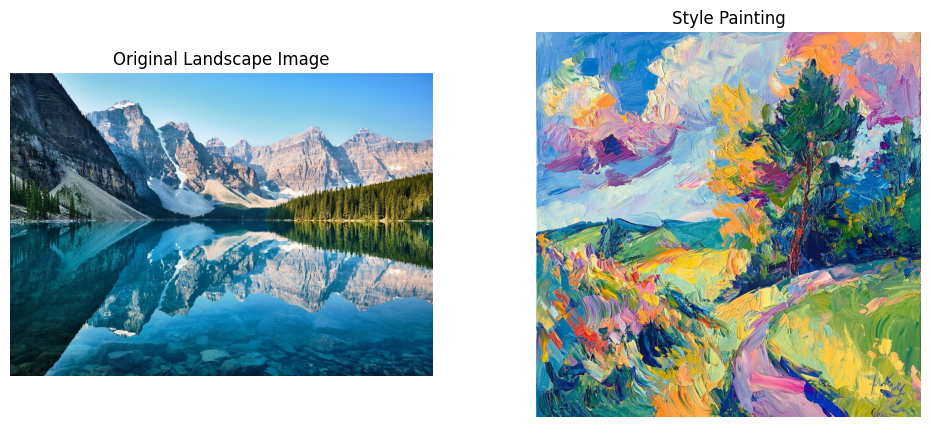

In [28]:
from PIL import Image
import matplotlib.pyplot as plt

content_image = Image.open("/content/landscape.jpg").convert("RGB")
style_image = Image.open("/content/style.jpg").convert("RGB")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(content_image)
plt.title("Original Landscape Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(style_image)
plt.title("Style Painting")
plt.axis("off")

plt.show()

## **8. Method 1: CycleGAN**

CycleGAN is a Generative Adversarial Network (GAN) designed for image-to-image translation.

Unlike traditional image translation methods, CycleGAN does not require paired images.

In this assignment, a pretrained CycleGAN model is used to transform the original landscape photograph into an artistic style.

The pretrained model is used directly, so no additional training is required.

### **Cycle Consistency**

CycleGAN uses the concept of cycle consistency.

If an image is translated from one domain to another and then translated back, the resulting image should remain similar to the original image.

For example:

Original Image → Artistic Style → Original Domain

This cycle consistency helps CycleGAN preserve important content while changing the visual style.

In [32]:
%cd /content/pytorch-CycleGAN-and-pix2pix

!pip install -q dominate visdom

import os

print("CycleGAN folder is ready!")
print("Current folder:", os.getcwd())

/content/pytorch-CycleGAN-and-pix2pix
CycleGAN folder is ready!
Current folder: /content/pytorch-CycleGAN-and-pix2pix


## **9. Download the Pretrained CycleGAN Model**

A pretrained CycleGAN model is used instead of training a new model from scratch.

The `style_monet` model is trained to translate photographs into a Monet-like artistic style.

This makes the process faster and suitable for this assignment.

In [33]:
%cd /content/pytorch-CycleGAN-and-pix2pix

!bash ./scripts/download_cyclegan_model.sh style_monet

/content/pytorch-CycleGAN-and-pix2pix
Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2026-10-02 09:41:00--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  48.0MB/s    in 0.9s    

2026-10-02 09:41:01 (48.0 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pt

## **10. Prepare the Dataset for CycleGAN**

CycleGAN expects input images to be placed inside a specific dataset folder.

The original landscape image is copied into the test folder.

This image will be used as the input for the pretrained `style_monet` model.

In [34]:
%cd /content/pytorch-CycleGAN-and-pix2pix

import os
import shutil

# Create the required test folder
os.makedirs("datasets/my_landscape/testA", exist_ok=True)

# Copy the original landscape image
shutil.copy(
    "/content/landscape.jpg",
    "datasets/my_landscape/testA/landscape.jpg"
)

print("Landscape image copied successfully!")
print("Location:")
print("/content/pytorch-CycleGAN-and-pix2pix/datasets/my_landscape/testA/landscape.jpg")

/content/pytorch-CycleGAN-and-pix2pix
Landscape image copied successfully!
Location:
/content/pytorch-CycleGAN-and-pix2pix/datasets/my_landscape/testA/landscape.jpg


## **11. Apply CycleGAN Style Transfer**

The pretrained `style_monet` CycleGAN model is applied to the original landscape image.

The model translates the photograph into a Monet-like artistic style while attempting to preserve the main structure and content of the original image.

No additional model training is performed.

In [35]:
%cd /content/pytorch-CycleGAN-and-pix2pix

!python test.py \
    --dataroot ./datasets/my_landscape \
    --name style_monet_pretrained \
    --model test \
    --no_dropout \
    --preprocess resize

/content/pytorch-CycleGAN-and-pix2pix
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/my_landscape       	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
     

## **12. CycleGAN Output**

The pretrained CycleGAN model has transformed the original landscape photograph into a Monet-like artistic style.

The generated image is now displayed below and will be used later for comparison with the Neural Style Transfer result.

In [36]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# CycleGAN output folder
output_folder = "/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images"

print("Files generated by CycleGAN:")

for file in os.listdir(output_folder):
    print(file)

Files generated by CycleGAN:
landscape_fake.png
landscape_real.png


## **13. Visualizing the CycleGAN Result**

The generated CycleGAN image is displayed alongside the original landscape image.

The `landscape_fake.png` image represents the output produced by the pretrained CycleGAN model.

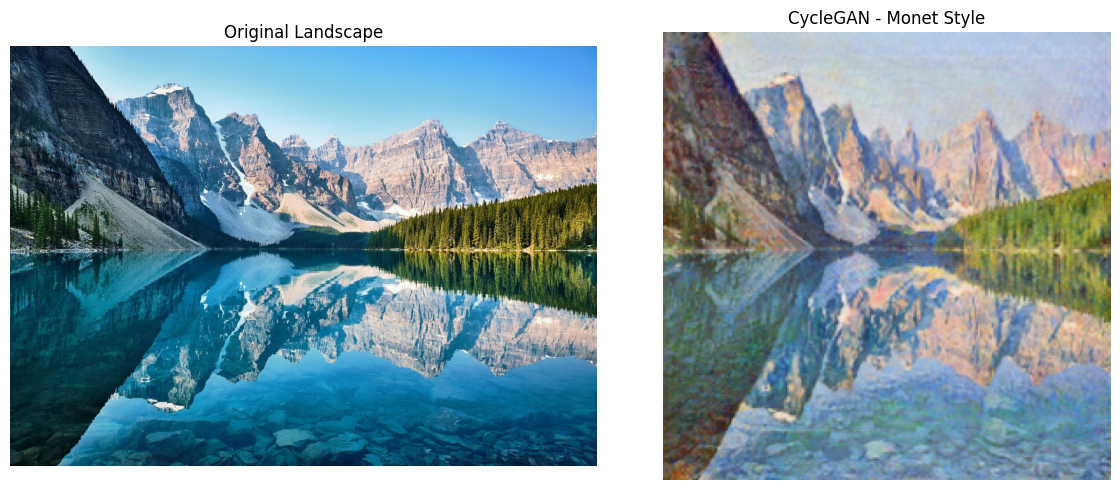

In [37]:
from PIL import Image
import matplotlib.pyplot as plt

# Load images
original = Image.open("/content/landscape.jpg").convert("RGB")
cyclegan_output = Image.open(
    "/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images/landscape_fake.png"
).convert("RGB")

# Display side by side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Landscape")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cyclegan_output)
plt.title("CycleGAN - Monet Style")
plt.axis("off")

plt.tight_layout()
plt.show()

## **14. Method 2: Neural Style Transfer**

Neural Style Transfer (NST) is a deep learning technique that combines the content of one image with the artistic style of another image.

In this assignment:

- The **landscape image** provides the content.
- The **painting** provides the artistic style.
- A pretrained **VGG19** network is used to extract content and style features.

The goal is to preserve the important structure of the landscape while applying the visual characteristics of the painting.

## **15. Load the Pretrained VGG19 Network**

VGG19 is a pretrained convolutional neural network commonly used for Neural Style Transfer.

Different layers of VGG19 capture different types of information:

- Earlier layers capture simple features such as edges and textures.
- Deeper layers capture more complex shapes and content.

The network is used only for feature extraction and its weights are not modified.

In [38]:
import torch
import torchvision.models as models

# Load pretrained VGG19
vgg = models.vgg19(
    weights=models.VGG19_Weights.DEFAULT
).features.to(device)

# Evaluation mode
vgg.eval()

# Freeze VGG19 parameters
for param in vgg.parameters():
    param.requires_grad = False

print("VGG19 loaded successfully!")
print("Using device:", device)

VGG19 loaded successfully!
Using device: cuda


## **16. Load and Preprocess the Images**

The same landscape image used for CycleGAN is used as the content image.

The painting is used as the style image.

Both images are resized to 512 × 512 pixels and converted into PyTorch tensors so that they can be processed by the VGG19 network.

In [39]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Image size
image_size = 512

# Preprocessing transformation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# Load the content image
content_image = Image.open("/content/landscape.jpg").convert("RGB")

# Load the style image
style_image = Image.open("/content/style.jpg").convert("RGB")

# Convert images to tensors
content = transform(content_image).unsqueeze(0).to(device)
style = transform(style_image).unsqueeze(0).to(device)

print("Content image tensor shape:", content.shape)
print("Style image tensor shape:", style.shape)

Content image tensor shape: torch.Size([1, 3, 512, 512])
Style image tensor shape: torch.Size([1, 3, 512, 512])


## **17. Select Content and Style Layers**

For Neural Style Transfer, different VGG19 layers are used to extract different types of features.

### **Content Layer**

A deeper layer is selected to capture the main structure and content of the landscape.

### **Style Layers**

Multiple layers are selected to capture artistic features such as:

- Colors
- Textures
- Edges
- Patterns

The selected layers are used to calculate the content and style representations of the images.

In [40]:
# Content layer
content_layers = ['21']

# Style layers
style_layers = ['0', '5', '10', '19', '28']

print("Content layer:", content_layers)
print("Style layers:", style_layers)

Content layer: ['21']
Style layers: ['0', '5', '10', '19', '28']


## **18. Extract Content and Style Features**

The pretrained VGG19 network is used to extract features from the content and style images.

The selected layers provide:

- **Content features:** Information about the structure and objects in the landscape.
- **Style features:** Information about colors, textures, patterns, and artistic appearance.

These extracted features are later used to calculate the content loss and style loss.

In [41]:
def get_features(image, model, layers):
    features = {}

    x = image

    for name, layer in model._modules.items():
        x = layer(x)

        if name in layers:
            features[name] = x

    return features


# Extract content features
content_features = get_features(
    content,
    vgg,
    content_layers
)

# Extract style features
style_features = get_features(
    style,
    vgg,
    style_layers
)

print("Content features extracted:", list(content_features.keys()))
print("Style features extracted:", list(style_features.keys()))

Content features extracted: ['21']
Style features extracted: ['0', '5', '10', '19', '28']


## **19. Calculate the Gram Matrix**

The Gram Matrix is used in Neural Style Transfer to represent the style of an image.

It captures relationships between different feature maps produced by the VGG19 network.

The Gram Matrix helps represent visual characteristics such as:

- Texture
- Patterns
- Colors
- Artistic appearance

The style features of the painting are converted into Gram Matrices and compared with the generated image during optimization.

In [42]:
def gram_matrix(tensor):
    """
    Calculate the Gram Matrix for a feature tensor.
    """
    batch_size, depth, height, width = tensor.size()

    # Reshape feature maps
    features = tensor.view(batch_size * depth, height * width)

    # Calculate Gram Matrix
    gram = torch.mm(features, features.t())

    # Normalize
    gram = gram / (batch_size * depth * height * width)

    return gram


# Calculate Gram matrices for the style image
style_grams = {}

for layer in style_layers:
    style_grams[layer] = gram_matrix(style_features[layer])

print("Gram matrices calculated successfully!")

for layer in style_grams:
    print("Layer", layer, ":", style_grams[layer].shape)

Gram matrices calculated successfully!
Layer 0 : torch.Size([64, 64])
Layer 5 : torch.Size([128, 128])
Layer 10 : torch.Size([256, 256])
Layer 19 : torch.Size([512, 512])
Layer 28 : torch.Size([512, 512])


## **20. Create the Target Image**

The target image is initialized as a copy of the original landscape image.

During Neural Style Transfer, this target image is gradually modified.

The optimization process tries to:

- Keep the content similar to the original landscape.
- Make the visual style similar to the selected painting.

The target image is the final Neural Style Transfer output.

In [43]:
# Start with a copy of the original content image
target = content.clone().requires_grad_(True)

print("Target image created successfully!")
print("Target shape:", target.shape)

Target image created successfully!
Target shape: torch.Size([1, 3, 512, 512])


## **21. Content Loss and Style Loss**

Neural Style Transfer uses two main types of loss.

### **Content Loss**

Content loss measures how different the generated image is from the original landscape in terms of its important visual structure.

A lower content loss means the generated image preserves the original content more closely.

### **Style Loss**

Style loss measures how different the generated image is from the painting in terms of texture, colors, and patterns.

A lower style loss means the generated image is visually closer to the selected painting.

The total loss combines both content loss and style loss.

In [44]:
# Content weight and style weight
content_weight = 1
style_weight = 1000000

# Optimizer
optimizer = torch.optim.Adam([target], lr=0.003)

print("Content weight:", content_weight)
print("Style weight:", style_weight)
print("Optimizer: Adam")

Content weight: 1
Style weight: 1000000
Optimizer: Adam


## **22. Perform Neural Style Transfer**

The target image is optimized using the Adam optimizer.

During each iteration:

1. Features are extracted from the target image using VGG19.
2. Content loss is calculated by comparing the target with the original landscape.
3. Style loss is calculated by comparing the Gram Matrices of the target and the painting.
4. The total loss is calculated.
5. The target image is updated to reduce the total loss.

After several iterations, the target image contains the content of the landscape and the visual characteristics of the painting.

In [45]:
num_steps = 500

print("Starting Neural Style Transfer...")
print("Total steps:", num_steps)

for step in range(1, num_steps + 1):

    # Extract features from target image
    target_features = get_features(
        target,
        vgg,
        content_layers + style_layers
    )

    # Content loss
    content_loss = torch.mean(
        (target_features['21'] - content_features['21']) ** 2
    )

    # Style loss
    style_loss = 0

    for layer in style_layers:
        target_gram = gram_matrix(target_features[layer])

        style_loss += torch.mean(
            (target_gram - style_grams[layer]) ** 2
        )

    # Total loss
    total_loss = (
        content_weight * content_loss +
        style_weight * style_loss
    )

    # Optimization
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # Keep pixel values between 0 and 1
    with torch.no_grad():
        target.clamp_(0, 1)

    # Display progress
    if step % 50 == 0:
        print(
            f"Step {step}/{num_steps} | "
            f"Content Loss: {content_loss.item():.4f} | "
            f"Style Loss: {style_loss.item():.4f} | "
            f"Total Loss: {total_loss.item():.4f}"
        )

print("Neural Style Transfer completed!")

Starting Neural Style Transfer...
Total steps: 500
Step 50/500 | Content Loss: 0.8130 | Style Loss: 0.0000 | Total Loss: 1.3420
Step 100/500 | Content Loss: 0.6878 | Style Loss: 0.0000 | Total Loss: 1.0866
Step 150/500 | Content Loss: 0.6385 | Style Loss: 0.0000 | Total Loss: 0.9934
Step 200/500 | Content Loss: 0.6096 | Style Loss: 0.0000 | Total Loss: 0.9392
Step 250/500 | Content Loss: 0.5900 | Style Loss: 0.0000 | Total Loss: 0.9017
Step 300/500 | Content Loss: 0.5754 | Style Loss: 0.0000 | Total Loss: 0.8739
Step 350/500 | Content Loss: 0.5639 | Style Loss: 0.0000 | Total Loss: 0.8516
Step 400/500 | Content Loss: 0.5542 | Style Loss: 0.0000 | Total Loss: 0.8332
Step 450/500 | Content Loss: 0.5462 | Style Loss: 0.0000 | Total Loss: 0.8177
Step 500/500 | Content Loss: 0.5396 | Style Loss: 0.0000 | Total Loss: 0.8046
Neural Style Transfer completed!


## **23. Neural Style Transfer Output**

The optimized target image is now displayed.

The result should preserve the main content and structure of the original landscape while incorporating visual characteristics from the selected painting.

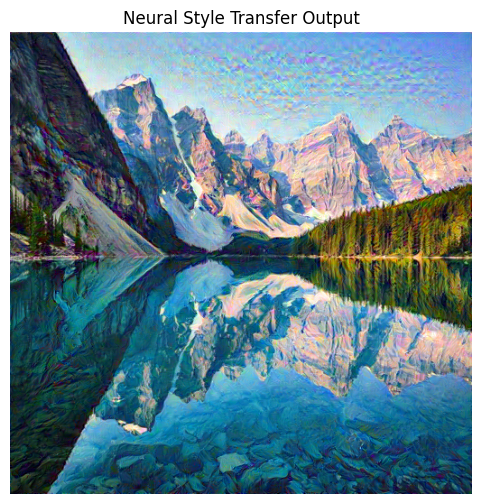

In [46]:
import matplotlib.pyplot as plt

# Move target image to CPU
nst_output = target.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()

# Display NST result
plt.figure(figsize=(8, 6))

plt.imshow(nst_output)
plt.title("Neural Style Transfer Output")
plt.axis("off")

plt.show()

## **24. Save the Neural Style Transfer Output**

The generated Neural Style Transfer image is saved as a JPG file so that it can be used in the final comparison.

In [47]:
from PIL import Image

# Convert output to an image
nst_image = Image.fromarray(
    (nst_output * 255).clip(0, 255).astype("uint8")
)

# Save the image
nst_image.save("/content/neural_style_transfer_output.jpg")

print("NST output saved successfully!")
print("/content/neural_style_transfer_output.jpg")

NST output saved successfully!
/content/neural_style_transfer_output.jpg


## **25. Comparison of Style Transfer Methods**

The original landscape image and the outputs from both style transfer methods are compared side by side.

The three images are:

1. Original Landscape Image
2. CycleGAN Output
3. Neural Style Transfer Output

This comparison helps us observe how each method changes the visual appearance while preserving the original content.

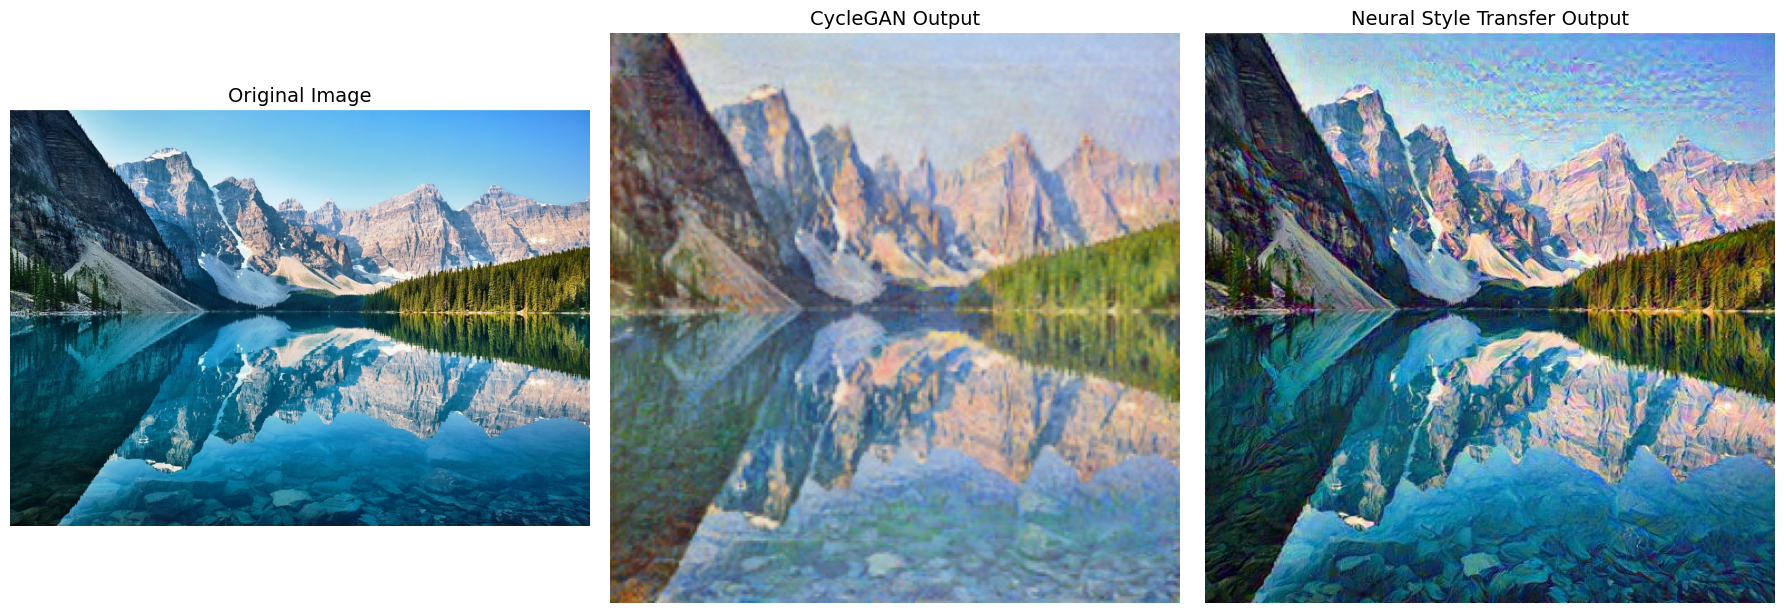

In [48]:
from PIL import Image
import matplotlib.pyplot as plt

# Load all three images
original = Image.open("/content/landscape.jpg").convert("RGB")

cyclegan_output = Image.open(
    "/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images/landscape_fake.png"
).convert("RGB")

nst_output_image = Image.open(
    "/content/neural_style_transfer_output.jpg"
).convert("RGB")

# Create comparison figure
plt.figure(figsize=(18, 6))

# Original
plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Image", fontsize=14)
plt.axis("off")

# CycleGAN
plt.subplot(1, 3, 2)
plt.imshow(cyclegan_output)
plt.title("CycleGAN Output", fontsize=14)
plt.axis("off")

# Neural Style Transfer
plt.subplot(1, 3, 3)
plt.imshow(nst_output_image)
plt.title("Neural Style Transfer Output", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()

## **26. Save the Final Comparison**

The three-image comparison is saved as a single image for inclusion in the assignment report.

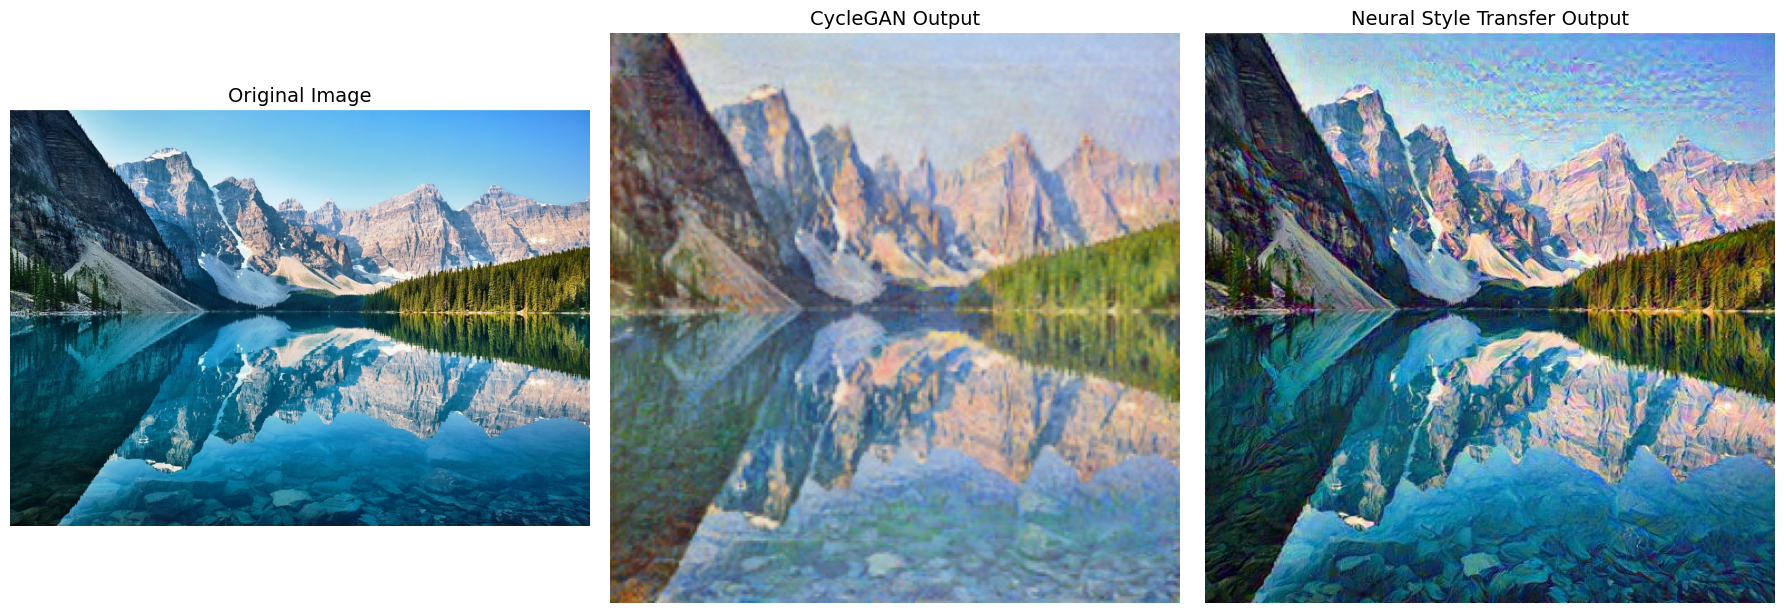

Comparison saved successfully!
/content/Assignment_6_Comparison.png


In [49]:
comparison_path = "/content/Assignment_6_Comparison.png"

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Image", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cyclegan_output)
plt.title("CycleGAN Output", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(nst_output_image)
plt.title("Neural Style Transfer Output", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

print("Comparison saved successfully!")
print(comparison_path)

## **27. Comparison of CycleGAN and Neural Style Transfer**

| Feature | CycleGAN | Neural Style Transfer |
|---|---|---|
| Main purpose | Image-to-image translation | Artistic style transfer |
| Model used | Pretrained CycleGAN | Pretrained VGG19 |
| Input | Original landscape image | Content image + style painting |
| Style | Monet-like style learned by the model | Style taken from the selected painting |
| Content preservation | Preserves the main structure of the input image | Preserves the content while applying painting features |
| Training for this assignment | No additional training | No additional training |
| Main technique | Adversarial learning and cycle consistency | Content loss and style loss |

## **28. Result Comparison**

The original image preserves the natural appearance of the landscape. CycleGAN transforms the image into a Monet-like artistic style while maintaining the major structures of the original scene. Neural Style Transfer combines the content of the landscape with the visual characteristics of the selected painting, producing changes in texture, colors, and patterns. The two methods demonstrate different approaches to achieving artistic image transformation.

## **29. Cycle Consistency in CycleGAN**

Cycle consistency is an important concept in CycleGAN.

The model learns two transformations between two image domains. If an image is translated from the first domain to the second domain and then translated back, the reconstructed image should remain similar to the original image.

For example:

Original Photograph → Artistic Domain → Reconstructed Photograph

This helps the model perform image translation while preserving important information from the original image.

## **30. Conclusion**

In this assignment, two AI-based style transfer techniques were applied to the same landscape image.

CycleGAN used a pretrained model to translate the photograph into a Monet-like artistic domain. Neural Style Transfer used VGG19 to combine the content of the landscape with the style of a selected painting.

The experiment demonstrates how different deep learning approaches can generate artistic transformations while retaining important visual information from the original image.

## **31. Final Result**

The final comparison consists of three images:

1. Original Landscape Image
2. CycleGAN Output
3. Neural Style Transfer Output

These results demonstrate the difference between domain-based image translation using CycleGAN and painting-based artistic style transfer using Neural Style Transfer.